In [2]:
import pandas as pd
import numpy as np

#This is the dataset that will be analyzed in order to investigate how surface areas
#in buildings affect heating load, which impacts the amount of energy
#used to heat and cool buildings in kWh

#These values are in meters squared while the load variables are in kWh
#They were derived from simulations in Ecotect, an architectural website

df = pd.read_csv("Regression.csv")


print(df.head())
print(df.info())
print(df.isnull().sum())

   Relative_Compactness  Surface_Area  Wall_Area  Roof_Area  Overall_Height  \
0                  0.98         514.5      294.0     110.25             7.0   
1                  0.98         514.5      294.0     110.25             7.0   
2                  0.98         514.5      294.0     110.25             7.0   
3                  0.98         514.5      294.0     110.25             7.0   
4                  0.90         563.5      318.5     122.50             7.0   

   Orientation  Glazing_Area  Glazing_Area_Distribution  Heating_Load  \
0            2           0.0                          0         15.55   
1            3           0.0                          0         15.55   
2            4           0.0                          0         15.55   
3            5           0.0                          0         15.55   
4            2           0.0                          0         20.84   

   Cooling_Load  
0         21.33  
1         21.33  
2         21.33  
3         21.3

Chowdhury, U. (2022). Energy Efficiency Data Set. Kaggle.com. https://www.kaggle.com/datasets/ujjwalchowdhury/energy-efficiency-data-set

In [3]:
#The objective of using this Kaggle dataset is to classify these variables that affect the heating load in buildings
target = "Heating_Load"
features = [
    "Relative_Compactness", "Surface_Area", "Wall_Area",
    "Roof_Area", "Orientation", "Glazing_Area"
]

X = df[features]
y = df[target]

In [4]:
# Split data into training and test sets (80%/20%) for unbiased model evaluation
# This ensures reproducibility (random_state=42) and mimics real-world train/test separation

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Shape:", X_train.shape)

Shape: (614, 6)


scikit-learn. (2018). sklearn.model_selection.train_test_split — scikit-learn 0.20.3 documentation. Scikit-Learn.org. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

In [5]:

#Decision Tree Regressor
#Single-tree model that predicts continuous targets
#Splits data into branches based on feature values to make predictions
#GridSearchCV used to find the best hyperparameters automatically
#cv=5: 5-fold cross-validation estimates performance on unseen data
#Scoring: neg_root_mean_squared_error (lower RMSE = better predictions)

#Hyperparameters:
#max_depth: maximum depth of the tree; controls complexity and prevents overfitting
#min_samples_split: minimum number of samples required to split a node; prevents splits on tiny groups
#min_samples_leaf: minimum number of samples required in a leaf; ensures stable predictions
#max_features: number of features considered for each split ("sqrt" adds randomness)

#Outcome:
#GridSearchCV evaluates all combinations of parameters,
#selects the tree that generalizes best, balancing bias and variance


from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5, 8, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [None, "sqrt"]
}

dt = DecisionTreeRegressor(random_state=42)
dt_cv = GridSearchCV(dt, param_grid, cv=5, scoring="neg_root_mean_squared_error")
dt_cv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42),
             param_grid={'max_depth': [3, 5, 8, None],
                         'max_features': [None, 'sqrt'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='neg_root_mean_squared_error')

scikit-learn. (2025). sklearn.tree.DecisionTreeRegressor — scikit-learn 0.23.2 documentation. Scikit-Learn.org. https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html

‌scikit-learn. (2019). sklearn.model_selection.GridSearchCV — scikit-learn 0.22 Documentation. Scikit-Learn.org. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

In [6]:
#Random Forest Regressor
#Ensemble method: combines many decision trees to improve accuracy
#Each tree sees a random subset of data and features → reduces overfitting
#GridSearchCV used to find the best hyperparameters
#cv=5: 5-fold cross-validation estimates performance on unseen data
#Scoring: neg_root_mean_squared_error (lower RMSE = better predictions)

#Hyperparameters:
#n_estimators: number of trees in the forest; more trees → more stable predictions
#max_depth: maximum depth of each tree; controls tree complexity
#max_features: features considered for each split ("sqrt" or "log2"); adds randomness to decorrelate trees

#Outcome:
#GridSearchCV tests all combinations of n_estimators, max_depth, and max_features,
#selects the model that generalizes best, balancing bias and variance

from sklearn.ensemble import RandomForestRegressor

rf_param = {
    "n_estimators": [50, 100, 200],
    "max_depth": [5, 8, None],
    "max_features": ["sqrt", "log2"]
}

rf = RandomForestRegressor(random_state=42)
rf_cv = GridSearchCV(rf, rf_param, cv=5, scoring="neg_root_mean_squared_error")
rf_cv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [5, 8, None],
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': [50, 100, 200]},
             scoring='neg_root_mean_squared_error')

‌scikit-learn. (2019). sklearn.model_selection.GridSearchCV — scikit-learn 0.22 Documentation. Scikit-Learn.org. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

scikit-learn. (2018). 3.2.4.3.2. sklearn.ensemble.RandomForestRegressor — scikit-learn 0.20.3 documentation. Scikit-Learn.org. https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

In [7]:
#Decision Tree Regressor
#Single-tree model that predicts continuous targets
#Splits data into branches based on feature values to make predictions
#GridSearchCV used to find the best hyperparameters automatically
#cv=5: 5-fold cross-validation estimates performance on unseen data
#Scoring: neg_root_mean_squared_error (lower RMSE = better predictions)

#Hyperparameters:
#max_depth: maximum depth of the tree; controls complexity and prevents overfitting
#min_samples_split: minimum number of samples required to split a node; prevents splits on tiny groups
#min_samples_leaf: minimum number of samples required in a leaf; ensures stable predictions
#max_features: number of features considered for each split ("sfqrt" adds randomness)

#Outcome:
#GridSearchCV evaluates all combinations of parameters,
#selects the tree that generalizes best, balancing bias and variance


from sklearn.ensemble import GradientBoostingRegressor

gb_param = {
    "n_estimators": [100, 200],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.05, 0.1, 0.2]
}

gb = GradientBoostingRegressor(random_state=42)
gb_cv = GridSearchCV(gb, gb_param, cv=5, scoring="neg_root_mean_squared_error")
gb_cv.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=GradientBoostingRegressor(random_state=42),
             param_grid={'learning_rate': [0.05, 0.1, 0.2],
                         'max_depth': [3, 4, 5], 'n_estimators': [100, 200]},
             scoring='neg_root_mean_squared_error')

‌scikit-learn. (2019). sklearn.model_selection.GridSearchCV — scikit-learn 0.22 Documentation. Scikit-Learn.org. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html

scikit-learn. (2025). GradientBoostingRegressor. Scikit-Learn.org.https://scikit-learn.org/1.6/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html

In [10]:

#Evaluate_model evaluates all of the regression models on test data
#Calculates three common to assess prediction quality:
#RMSE: average magnitude of errors, penalizes large errors
#MAE: average absolute difference between predictions and true values
#R²: proportion of variance explained by the model

#Trained regression models (Decision Tree, Random Forest, Gradient Boosting)
#X_test: features for testing
#y_test: true target values for testing





from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(model, X_test, y_test, name):
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    print(f"{name} → RMSE: {rmse:.3f}, MAE: {mae:.3f}, R²: {r2:.3f}")
    return {"Model": name, "RMSE": rmse, "MAE": mae, "R²": r2}

results = []
results.append(evaluate_model(dt_cv.best_estimator_, X_test, y_test, "Decision Tree"))
results.append(evaluate_model(rf_cv.best_estimator_, X_test, y_test, "Random Forest"))
results.append(evaluate_model(gb_cv.best_estimator_, X_test, y_test, "Gradient Boosting"))


pd.DataFrame(results)

Decision Tree → RMSE: 0.668, MAE: 0.469, R²: 0.996
Random Forest → RMSE: 0.842, MAE: 0.559, R²: 0.993
Gradient Boosting → RMSE: 0.524, MAE: 0.386, R²: 0.997


,Model,RMSE,MAE,R²
0,Decision Tree,0.668432,0.468676,0.995713
1,Random Forest,0.841553,0.559012,0.993205
2,Gradient Boosting,0.523916,0.386365,0.997367


scikit-learn. (2022). 3.4. Metrics and scoring: quantifying the quality of predictions. Scikit-Learn.org.https://scikit-learn.org/1.6/modules/model_evaluation.html.

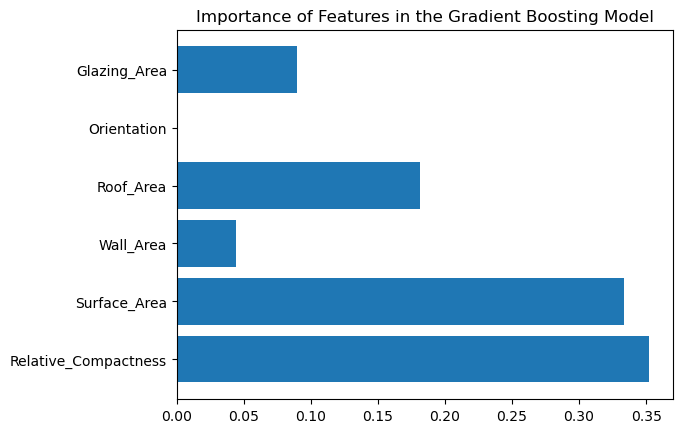

In [9]:
# The Gradient Boosting Model was plotted to display the importance of features in the model
# Creates a bar plot to show how important each feature is to the model
# The decimal values represent the relative contribution of each feature
# Higher values indicate greater influence on the model’s predictions

import matplotlib.pyplot as plt


best_tree = gb_cv.best_estimator_
importances = best_tree.feature_importances_
plt.barh(features, importances)
plt.title("Importance of Features in the Gradient Boosting Model")
plt.show()

scikit-learn (2026). Feature importances with a forest of trees. [online] scikit-learn. Available at: https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html.